We train the sea ice classification algorithm against a manually validated set of 16x16 pixel patches. We randomly selected either the Aqua or Terra scene from each of the 179 cases. We took a uniform random sample of 100 positions across the full 500 km by 500 km (2000 by 2000 pixel) scene. Positions within the land mask are rejected. The remaining points are considered for the following categories:
* cloud-free ice: MODIS cloud < 5%, ASI sea ice concentration > 85%
* cloud-free water: MODIS cloud < 5%, ASI sea ice concentration = 0%
* cloud-ice: MODIS cloud = 100%, ASI sea ice concentration > 85%
* cloud-water: MODIS cloud = 100%, ASI sea ice concentration < 5%
Samples are derived by first generating samples, and flagging the categories based on binary masks (ASI=0, ASI> 85%, cloud<5%, cloud=>95%). These are turned to a Shapefile with property tables. Then, in QGIS, we accept or reject samples according to each category. The final input labeled sample set contains the mean band 1, band 2, and band 7 reflectance, sample centers, sample bounding boxes, and binary columns `init_cloud_free_ice`, `init_cloud_free_water`, `init_cloud_ice`, `init_cloud_water` (the initial threshold base categories), and the manually assessed `cloud_free_ice`, `cloud_free_water`, `cloud_ice`, `cloud_water`. Ambiguous samples receive a `0` in all four categories.


# to do: scripts
- convert 500 km cloud fraction into PNG

In [195]:
import skimage.io as io
import os
import pandas as pd
import numpy as np

dataloc = "../../calval_tgrs/data/validation_dataset/modis_500km/cloudfraction/"
saveloc = "../../calval_tgrs/data/validation_dataset/modis_500km/cloudfraction_gray/"
plot_examples = True
recompute = False

key = io.imread("../data/metadata/color_key.png")
vals = pd.DataFrame(np.mean(key[:, :, :-1], axis=0), columns=['r', 'g', 'b']).round(0).astype(int)
bin_mean_values = vals.iloc[6::14,:].astype(int)[['r', 'g', 'b']]

n = len(bin_mean_values)
bin_edges = np.linspace(0, 100, n+1)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_mean_values.index = bin_centers

files = os.listdir(dataloc)
files = [f for f in files if '.tiff' in f]
files.sort()

for file in [files[15]]:
    cn, region, dx, suffix = file.split('-')
    date, satellite, imtype, res, ftype = suffix.split('.')
    cloudfrac_rgb = io
    case = cn + '_' + satellite
    rgb_img = io.imread(dataloc + file).astype(float)
    n, m, c = rgb_img.shape
    gray_img = np.zeros((n, m))

    pixel_min = lambda p: np.sqrt(np.sum((bin_mean_values - p)**2, axis=1)).idxmin()
    # for i in range(n):
    #     for j in range(m):
    #         p = rgb_img[i, j, :-1]
    #         gray_img[i, j] = np.sqrt(np.sum((bin_mean_values - p)**2, axis=1)).idxmin()
    break

In [196]:
bin_mean_values

,r,g,b
3.125,103,0,116
9.375,185,4,138
15.625,1,0,97
21.875,4,0,165
28.125,9,0,248
34.375,0,134,233
40.625,0,81,13
46.875,0,137,29
53.125,0,221,53
59.375,255,255,70


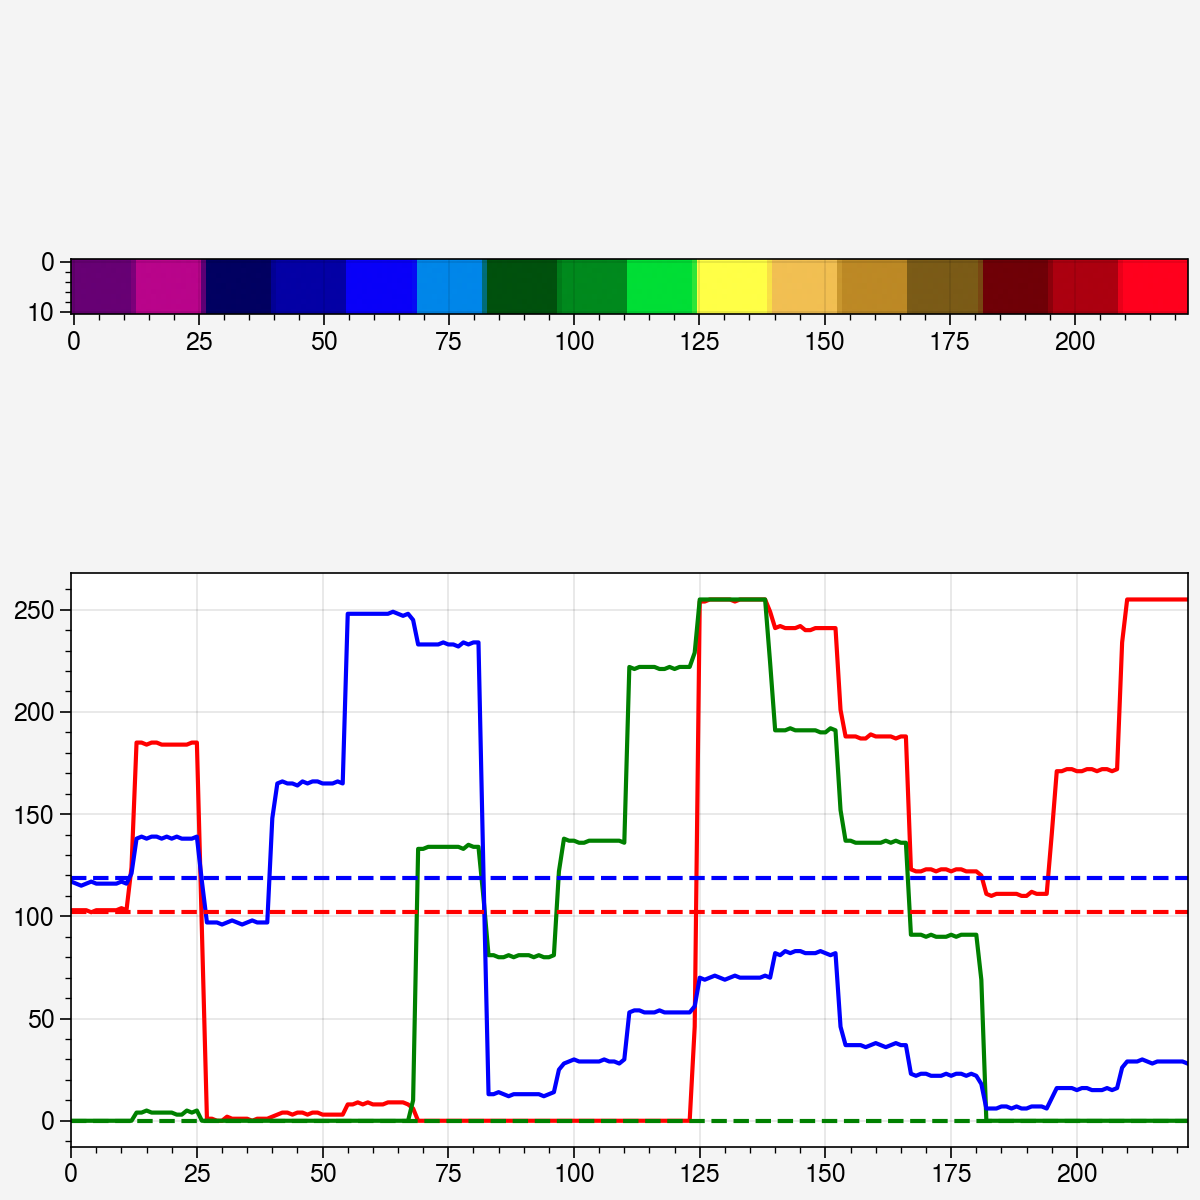

In [197]:
fig, ax = uplt.subplots(nrows=2, share=False, height=6, width=6)
ax[0].imshow(key)
ax[1].plot(key[5, :, 0], color='r')
ax[1].plot(key[5, :, 1], color='g')
ax[1].plot(key[5, :, 2], color='b')

ax[1].axhline(102, color='r', ls='--')
ax[1].axhline(0, color='g', ls='--')
ax[1].axhline(119, color='b', ls='--')

In [201]:
files[15]

'008-baffin_bay-500km-20110506.terra.cloudfraction.250m.tiff'

In [221]:
red = rgb_img[:, :, 0].astype(float)
green = rgb_img[:, :, 1].astype(float)
blue = rgb_img[:, :, 2].astype(float)
cloud_free = (green < 1) & (np.abs(red - 102) < 1) & (np.abs(blue - 119) < 1)
cloud_covered = (green < 6) & (red > 250) &  np.abs(blue < 30)

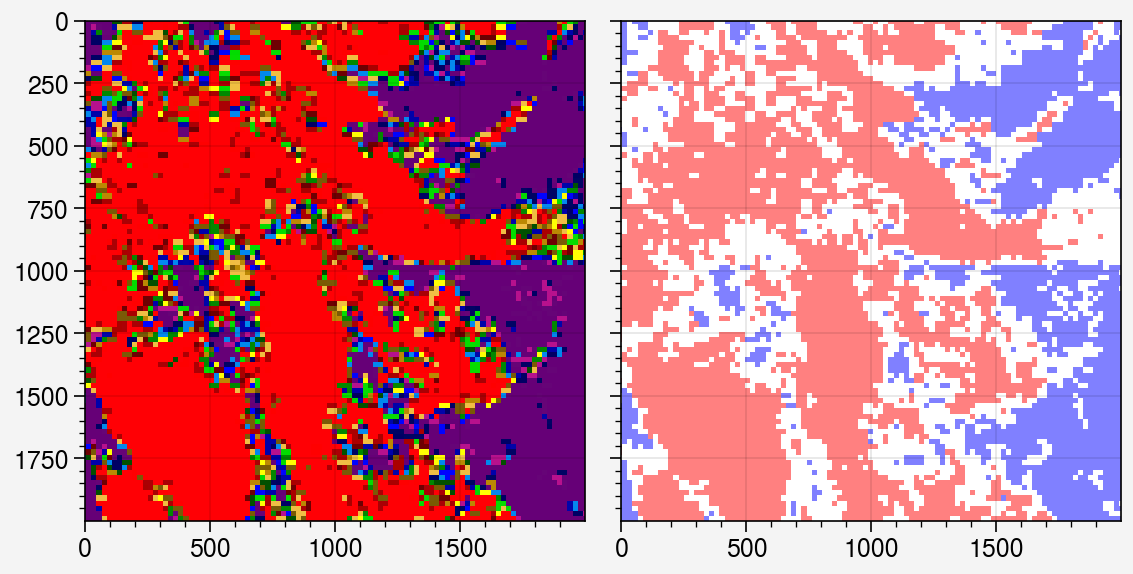

In [222]:
fig, ax = uplt.subplots(ncols=2)
ax[0].imshow(rgb_img.astype(int))
ax[1].imshow(np.ma.masked_array(cloud_free.astype(int), ~cloud_free), color='b', alpha=0.5)
ax[1].imshow(np.ma.masked_array(cloud_covered.astype(int), ~cloud_covered), color='r', alpha=0.5)

Selecting the extremes is faster than the pixel-to-percentage mapping. Since we are initializing a map of points to then verify

2d uniform random sample

In [310]:
g.choice(range(4, 20), (2, 4))

array([[16, 11,  7,  4],
       [18, 10, 19,  8]])

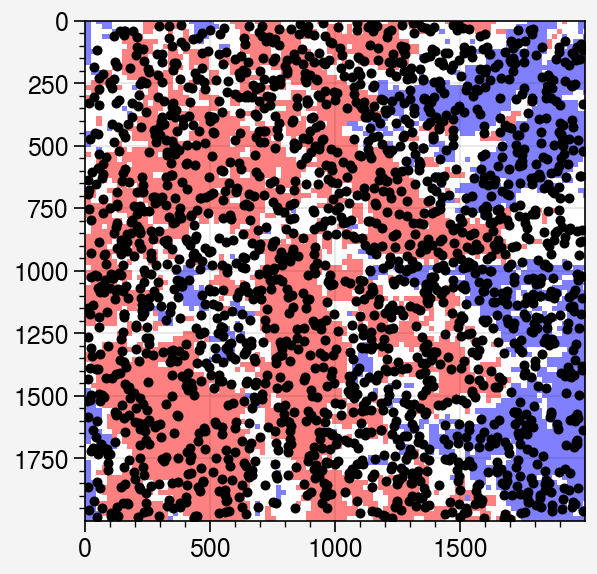

In [342]:
g = np.random.default_rng(seed=2340)
points = g.choice(range(8, 2000-8), (2, 2000)) 
fig, ax = uplt.subplots()
ax.imshow(np.ma.masked_array(cloud_free.astype(int), ~cloud_free), color='b', alpha=0.5)
ax.imshow(np.ma.masked_array(cloud_covered.astype(int), ~cloud_covered), color='r', alpha=0.5)
ax.scatter(points[0,:], points[1, :], color='k', marker='.')

We draw a random sample of locations within each index with the constraint that points are separated by at least 10 km, which is two pixels in the cloud mask product.

In [356]:
import scipy
# distance between all points
keep = np.ones(len(points[1, :]))
jcomp = np.arange(0, len(keep))
min_dx = 80
d = scipy.spatial.distance_matrix(points.T, points.T)
for i in range(1, len(keep)):
    if keep[i]:
        # d has the distance to every other point
        j = np.argwhere((d[i, :] < min_dx) & (i != jcomp))
        if len(j) > 0:
             keep[j] = 0
sample_points = points[:, keep > 0][:, 0:250]

In [357]:
len(sample_points.T)

250

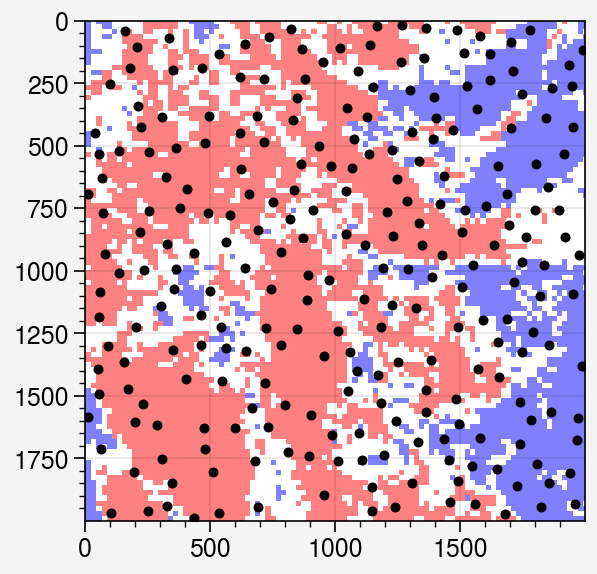

In [358]:
fig, ax = uplt.subplots()
ax.imshow(np.ma.masked_array(cloud_free.astype(int), ~cloud_free), color='b', alpha=0.5)
ax.imshow(np.ma.masked_array(cloud_covered.astype(int), ~cloud_covered), color='r', alpha=0.5)
ax.scatter(sample_points[0,:], sample_points[1, :], color='k', marker='.')

# Turning points to samples
- Expand using 16x16 template

In [359]:
Z = np.zeros((2000, 2000))
for idx in range(0, len(sample_points.T)):
    Z[points[0, idx], points[1, idx]] = 1
sample_patches = skim.dilation(Z, skim.footprint_rectangle((16,16)))
sample_patches = skimage.morphology.label(sample_patches)

In [360]:
np.max(sample_patches)


np.int64(240)

In [58]:
red = rgb_img[:, :, 0]
green = rgb_img[:, :, 1]
blue = rgb_img[:, :, 2]

In [188]:
rgb_img[50:60, 1800:1810]

array([[[  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.]],

       [[  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.]],

       [[  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [  4., 136.,   0., 255.],
        [ 

In [127]:
tol = 5
img = np.zeros((n, m))
for idx in [15]:
    data = bin_mean_values.iloc[idx, :]
    sel = np.abs(blue - data.b) < tol #) & (np.abs(green - data.g) < tol) & (np.abs(blue - data.b) < tol)
    img[sel] = idx

In [128]:
np.max(img)

np.float64(0.0)

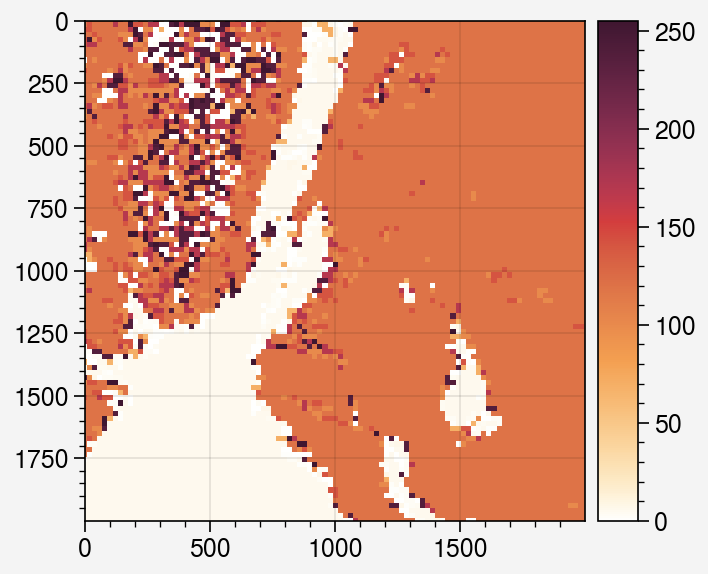

In [133]:
fig, ax  = uplt.subplots()
ax.imshow(blue, colorbar='r')

In [86]:
 data = bin_mean_values.iloc[idx, :]
    ax[idx, 0].imshow((np.abs(red - data.r) < 5).astype(int))

16

# Speeding this up: ~100% and ~0% cloud masks


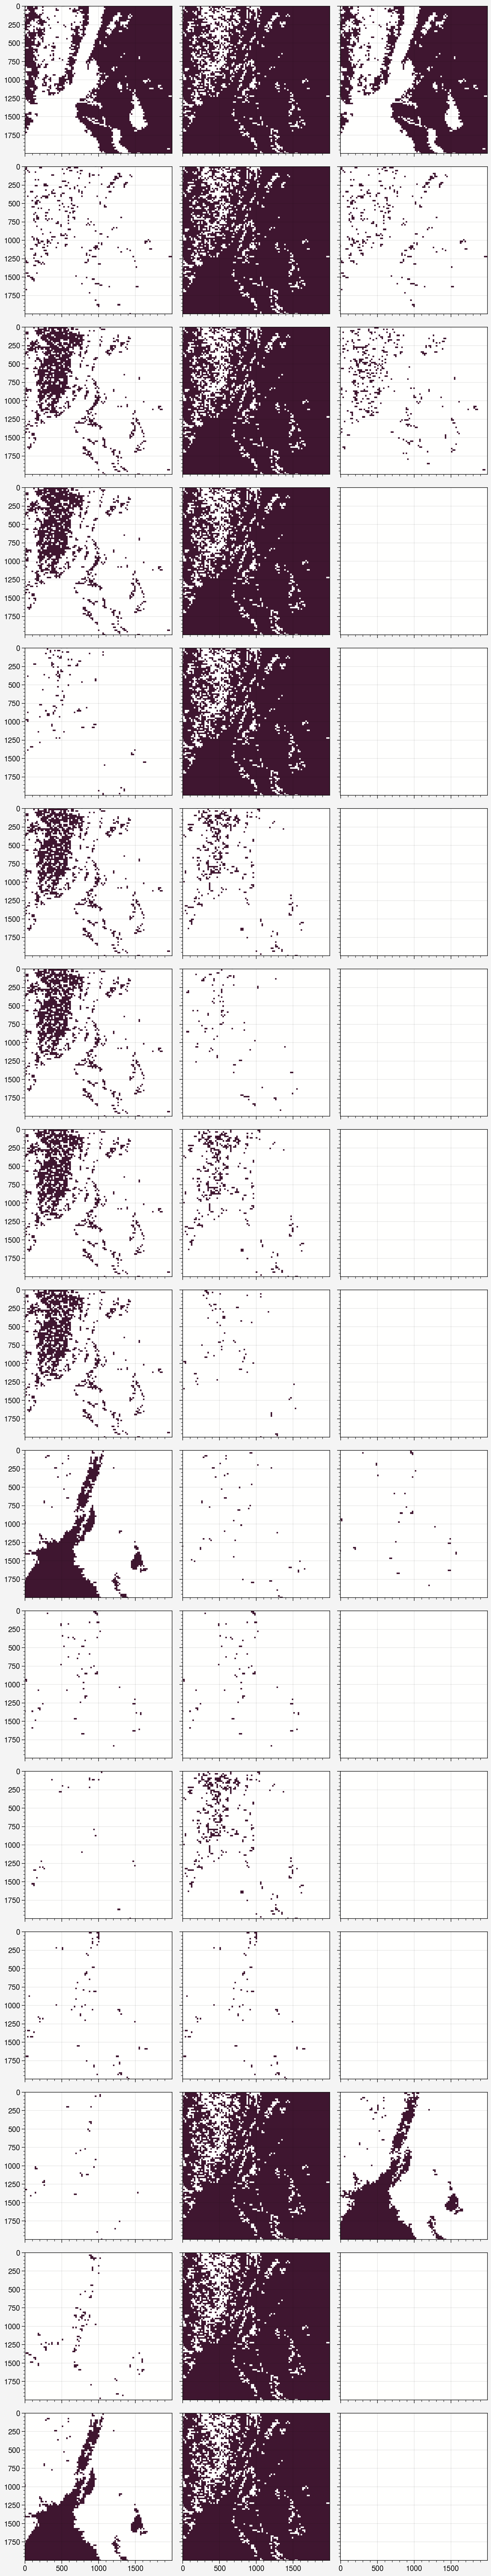

In [116]:
fig, ax = uplt.subplots(ncols=3, nrows=16)
for idx in range(0, len(bin_mean_values)):
    data = bin_mean_values.iloc[idx, :]
    ax[idx, 0].imshow((np.abs(red - data.r) < 5).astype(int))
    ax[idx, 1].imshow((np.abs(green - data.g) < 5).astype(int))
    ax[idx, 2].imshow((np.abs(blue - data.b) < 5).astype(int))

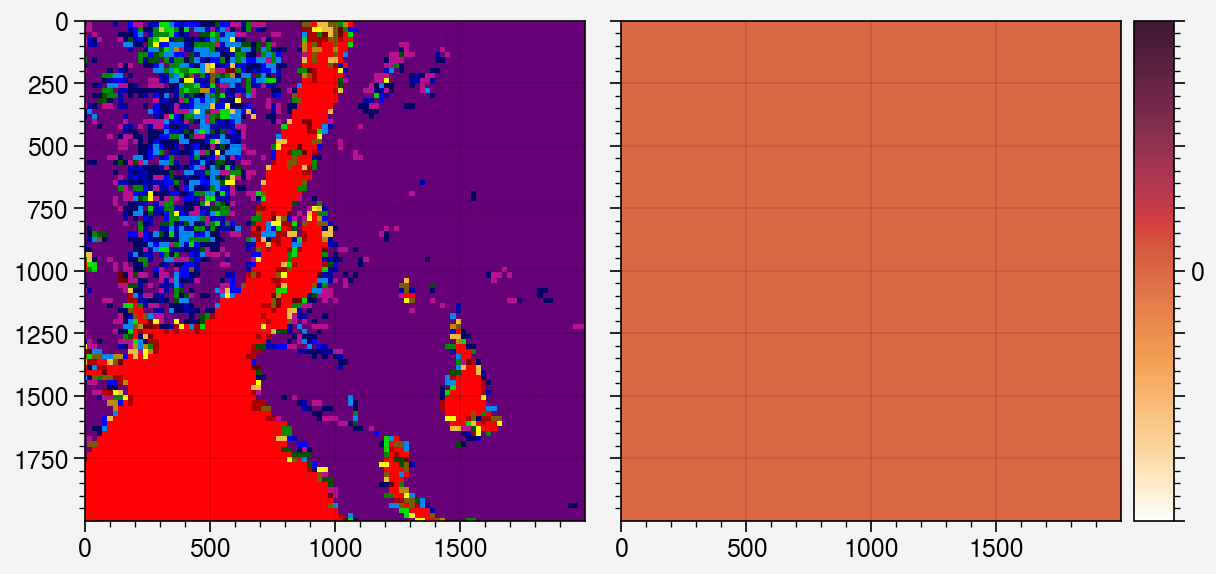

In [64]:
low_cloud_fraction = (np.abs(red - 103) < 5) # & (green <= 1) & (np.abs(blue - 116) < 5)
fig, ax = uplt.subplots(ncols=2)
ax[0].imshow(rgb_img)
ax[1].imshow(img, colorbar='r')


In [42]:
import skimage


Object `skimage.color.rgb_colors` not found.


In [26]:
%%time
gray_img = np.zeros((400, 400))
for i in range(400):
    for j in range(400):
        p = rgb_img[i, j, :-1]
        gray_img[i, j] = np.sqrt(np.sum((bin_mean_values - p)**2, axis=1)).idxmin()


CPU times: user 23.3 s, sys: 484 ms, total: 23.8 s
Wall time: 23.5 s


In [29]:
(2000 * 2000) / (400 * 400) * 23.5 / 60

9.791666666666666

In [23]:
# perhaps need to drop alpha channel?
pixel_min(rgb_img[0:200, 0:200, 0:3][0, 0])

np.float64(96.875)

In [4]:
import ultraplot as uplt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [40.625..78.125].


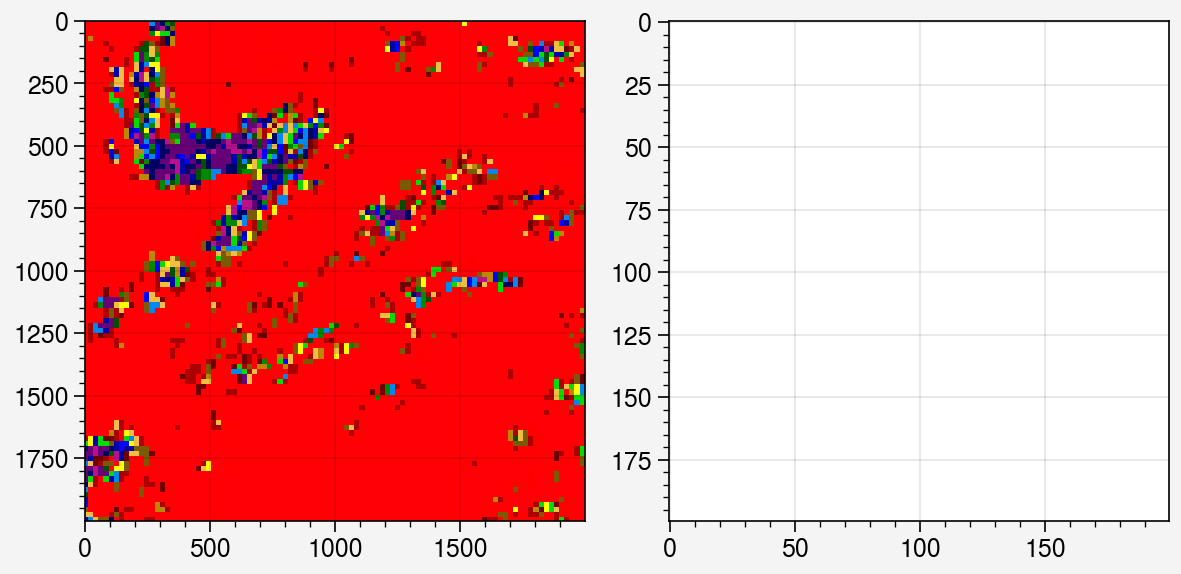

In [19]:
fig, ax = uplt.subplots(ncols=2, share=False)
ax[0].imshow(rgb_img)
ax[1].imshow(gray_img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [40.625..78.125].


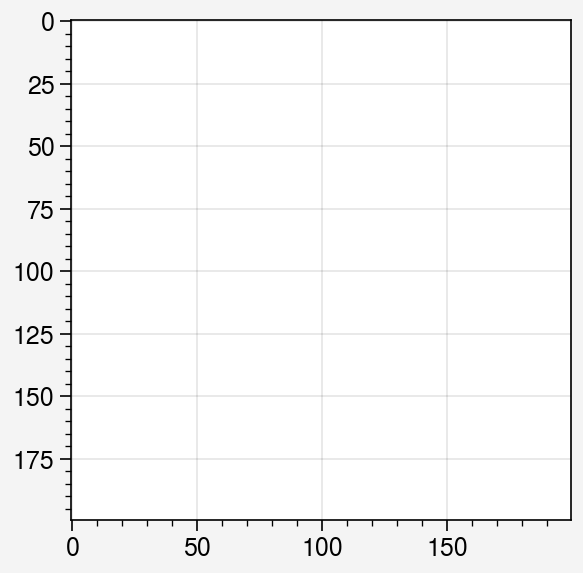

In [21]:
fig, ax = uplt.subplots()
ax.imshow(gray_img)